In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

In [2]:
from src.transforms import trainval_transforms, revert_normalization, revert_standardization
from src.dataset import ImageDataset
import torch

annot_path = Path("../data/preprocessed/trainval/annotations.csv")
img_dir = Path("../data/preprocessed/trainval/images")

# test dataset without transforms
dataset = ImageDataset(annot_path, img_dir, transform=trainval_transforms)

In [3]:
image, labels = next(iter(dataset))
obj_coords = []

In [4]:
revert_standardization(image)
image = revert_normalization(image)

In [5]:
from src.utilities import convert_xywh_coordinates

for i in range(7):
    for j in range(7):
        coord = labels[i][j][20:24]
        
        if torch.any(coord):
            obj_coords.append(
                convert_xywh_coordinates(coord, i, j, True)
            )
            obj_coords.append(
                convert_xywh_coordinates(coord, i, j, False)
            )

In [6]:
obj_coords

[(124, 111, 140, 131),
 (tensor(124.), tensor(111.), tensor(140.), tensor(131.)),
 (108, 116, 132, 178),
 (tensor(108.), tensor(115.5000), tensor(132.), tensor(178.5000)),
 (2, 146, 30, 224),
 (tensor(2.), tensor(146.), tensor(30.), tensor(224.)),
 (74, 158, 114, 222),
 (tensor(74.5000), tensor(157.5000), tensor(113.5000), tensor(222.5000)),
 (118, 126, 144, 202),
 (tensor(117.5000), tensor(126.), tensor(144.5000), tensor(202.))]

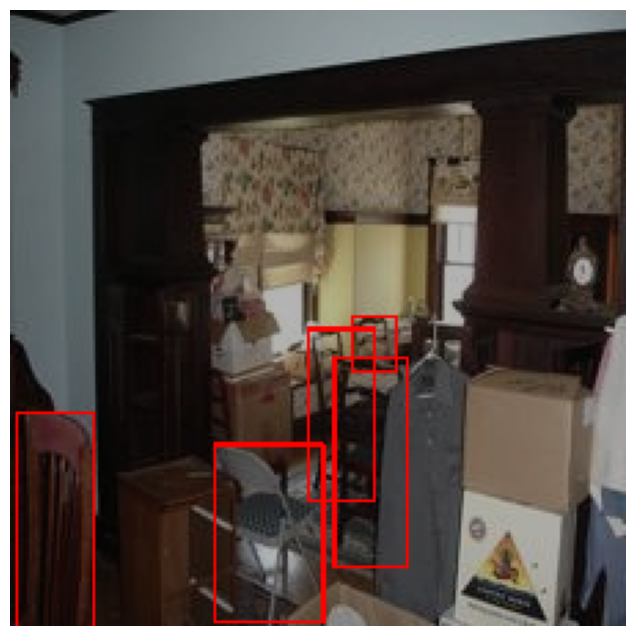

In [7]:
from matplotlib import pyplot as plt
import bbox_visualizer as bbv

fig, ax = plt.subplots(1, figsize=(8, 8))

image = image.permute(1, 2, 0).numpy()

image = bbv.draw_multiple_rectangles(image, obj_coords, bbox_color=(255, 0, 0), thickness=1)

ax.imshow(image)
ax.axis(False)

plt.show()

In [9]:
from src.utilities import IoU

# Test first on completely matched boxes
IoU_1 = IoU(obj_coords[1], obj_coords[1])

# Test second on completely unmatched boxes
IoU_2 = IoU(obj_coords[1], obj_coords[5])

# Test third on slightly matched boxes

print(IoU_1, IoU_2)
print(IoU_1 > IoU_2)

tensor(1.) tensor(0.)
tensor(True)
